# 01c. BAMIC on Wine Reviews: position-aware, selected-token normalized, best-validation checkpoint

This is a **new experimental variant** of `01_bamic_wine.ipynb`. The original
notebook and its completed Drive results remain unchanged. Run this notebook
top-to-bottom in a fresh Google Colab GPU runtime.

## What changes in this variant

1. **Learned positional embeddings** are added before both BAMIC attention
   branches, so token order is available to the model.
2. **Selected-token normalization** divides the gated sentiment numerator by
   the total selected-token mass rather than by document length. The returned
   `word_logit` is the normalized additive contribution and sums exactly to the
   document logit.
3. **Clean validation checkpointing** selects and saves a checkpoint using only
   a deterministic validation metric. Test data are not evaluated until the
   best validation checkpoint has been restored.
4. A **selection-mass floor guard** prevents the existing sparsity penalty from
   shrinking every gate toward zero after selected-token normalization.
5. All artifacts use the existing CSV/PNG/PT layout but are written to a new
   Drive folder whose name includes `posenc_selnorm_bestval`.

## Important comparison notes

- This notebook intentionally clears all old outputs. Do not compare a partial
  run with the completed legacy notebook.
- Normalized word contributions are on a different scale from legacy `Z=delta*r`.
  `gated_word_score` preserves that numerator; `word_logit` is now the additive
  contribution that sums to the document logit.
- Checkpoint selection defaults to validation NLL. Change `CHECKPOINT_METRIC`
  in the configuration cell to `acc` or `auc` only before starting a run.
- The experiment still uses the existing wine split. For a publishable final
  estimate, rebuild an untouched test protocol separately.

In [1]:
# ================================================================
# 0. Check the Colab GPU
# ================================================================

# Ask the Colab runtime which GPU we were given.
gpu_info = !nvidia-smi
# Join the command output lines into one printable string.
gpu_info = '\n'.join(gpu_info)
# If the command failed, we are not connected to a GPU runtime.
if gpu_info.find('failed') >= 0:
    print('Not connected to a GPU. In Colab: Runtime -> Change runtime type -> T4 GPU.')
else:
    print(gpu_info)

Wed Aug  5 16:40:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   32C    P0             49W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# ================================================================
# 1. Check the Colab RAM
# ================================================================

# psutil reports how much system memory this runtime has.
import psutil
# Convert bytes to gigabytes for a readable number.
ram_gb = psutil.virtual_memory().total / 1e9
# Print the available RAM so we know which runtime type we received.
print('Your runtime has {:.1f} gigabytes of available RAM'.format(ram_gb))

Your runtime has 179.4 gigabytes of available RAM


In [3]:
# ================================================================
# 2. Basic imports and reproducibility
# ================================================================

# pathlib gives clean, operating-system-safe file paths.
from pathlib import Path

# random controls Python-level randomness.
import random

# re is used for simple text cleaning and tokenization.
import re

# Counter helps build the vocabulary from token frequencies.
from collections import Counter

# numpy handles numeric arrays outside PyTorch.
import numpy as np

# pandas handles CSV data tables.
import pandas as pd

# torch is the deep learning framework used across all AMIC notebooks.
import torch

# nn contains PyTorch neural-network modules.
from torch import nn

# F contains functional operations such as relu, softmax, and softplus.
import torch.nn.functional as F

# Dataset and DataLoader create mini-batches for training.
from torch.utils.data import Dataset, DataLoader

# Metrics for classification quality and calibration.
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, brier_score_loss, log_loss

# matplotlib draws simple training curves.
import matplotlib.pyplot as plt

# math is used for square roots inside the attention block.
import math

# f1_score is also used directly by the threshold-tuning cell.
from sklearn.metrics import f1_score

# This seed keeps runs as reproducible as possible; it matches the wine BAMIC notebooks.
SEED = 20260526

# Seed Python's random module.
random.seed(SEED)

# Seed NumPy's random generator.
np.random.seed(SEED)

# Seed PyTorch's CPU generator.
torch.manual_seed(SEED)

# Seed all CUDA devices if a GPU is available.
torch.cuda.manual_seed_all(SEED)

# Pick the Colab GPU when available; otherwise fall back to CPU.
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Print the selected device so we know what this notebook is using.
print('Using device:', DEVICE)

Using device: cuda


## Step 1 — Lock the upgraded experiment configuration

Review this cell before running anything below it. The checkpoint metric and
aggregation mode must be chosen before training; changing them midway makes
the saved history and checkpoint incomparable.

In [4]:
# ================================================================
# 3. BAMIC configuration for this run (all knobs live in this one cell)
# ================================================================

# Freeze (True) or fine-tune (False) the GloVe embedding matrix. Frozen matches the
# published wine runs and is the safe default for review-level corpora.
FREEZE_EMBEDDINGS = True

# Maximum epochs; validation-only early stopping may finish sooner.
ABLATION_EPOCHS = 15

# Number of attention heads in each branch (300 must be divisible by this).
NUM_HEADS = 1

# WINE-SPECIFIC: trailing-boilerplate penalty. Wine reviews end with metadata such as
# "Drink now. 5,000 cases made." - Layer 1 must not select those tokens as sentiment
# evidence. 0.10 is the preferred value from the June grid search (the run that
# produced test acc 0.8620 / AUC 0.9456 / ECE 0.0706 and drove metadata contamination
# of the top-word list from 7 words to 0).
USE_BOILERPLATE_PENALTY = True
LAMBDA_BOILERPLATE = 0.10

# Soft stopword penalty strength. 0.01 is the wine-preferred value from the same grid
# (weaker than the 0.02 used on IMDB/Yelp: wine reviews are short, and some function
# words carry aging-window structure).
USE_STOPWORD_SELECTION_PENALTY = True
LAMBDA_STOPWORD = 0.01

# Do not double-penalize a token that is both a stopword and boilerplate
# (the boilerplate penalty takes precedence, as in the original notebook).
STOPWORD_PENALTY_EXCLUDES_BOILERPLATE = True

# Penalty warmup: BOTH penalties stay OFF for this many initial epochs so Layer 1
# first learns to select words at all. This is the collapse-prevention fix validated
# on IMDB and Yelp; the original wine runs predate it (they trained cleanly anyway,
# but the warmup is now the framework standard). Set 0 to reproduce the June setup.
STOPWORD_WARMUP_EPOCHS = 2

# Learning rate for AdamW (matches every BAMIC run in the project).
BAMIC_LEARNING_RATE = 3e-4

# Maximum word tokens per review. 100 covers every review in this corpus.
MAX_LEN = 100

# Mini-batch size. 128 (not the original 256) so the 25,000-review subsample still
# gives ~195 optimizer steps per epoch - cheap insurance for the selection gate,
# which likes many small steps (the ERASER collapse happened at ~100 long-document
# steps per epoch; wine's short reviews carry a much stronger per-word signal).
BATCH_SIZE = 128

# ------------------------------------------------------------------
# NEW 1/3: position-aware encoding and selected-token aggregation
# ------------------------------------------------------------------
USE_POSITIONAL_ENCODING = True
POSITION_ENCODING_TYPE = 'learned_absolute'
AGGREGATION_MODE = 'selected_token_mean'
AGGREGATION_EPS = 1e-6

# Selected-token normalization cancels a global rescaling of delta. Without
# this guard, the existing sparsity penalty can push all selection mass near
# zero while leaving the normalized prediction almost unchanged.
USE_SELECTION_FLOOR_GUARD = True
MIN_SELECTION_RATE = 0.05
# 0.50 is a conservative starting value: with LAMBDA_P2=0.01 and a 5%
# floor, 0.10 would not make an all-zero gate less attractive.
LAMBDA_SELECTION_FLOOR = 0.50

# ------------------------------------------------------------------
# NEW 2/3: validation-only checkpointing
# ------------------------------------------------------------------
# Choices: 'nll' or 'brier' (minimize), 'acc' or 'auc' (maximize).
CHECKPOINT_METRIC = 'nll'
CHECKPOINT_MIN_DELTA = 1e-4
EARLY_STOPPING_PATIENCE = 4

valid_checkpoint_metrics = {'nll', 'brier', 'acc', 'auc'}
if CHECKPOINT_METRIC not in valid_checkpoint_metrics:
    raise ValueError(f'CHECKPOINT_METRIC must be one of {valid_checkpoint_metrics}')
CHECKPOINT_MODE = 'min' if CHECKPOINT_METRIC in {'nll', 'brier'} else 'max'

# Build a self-describing experiment name. The new variant tag prevents this
# notebook from overwriting either the legacy ep10 or ep15 Drive folders.
freeze_tag = 'frozen' if FREEZE_EMBEDDINGS else 'unfrozen'
EXPERIMENT_NAME = (
    f'wine_bamic_posenc_selnorm_bestval_{freeze_tag}'
    f'_ep{ABLATION_EPOCHS}_heads{NUM_HEADS}'
    f'_lamB{str(LAMBDA_BOILERPLATE).replace(".", "p")}'
    f'_lamS{str(LAMBDA_STOPWORD).replace(".", "p")}_len{MAX_LEN}'
)

# Print the configuration so it is recorded in the notebook output.
print('FREEZE_EMBEDDINGS      :', FREEZE_EMBEDDINGS)
print('ABLATION_EPOCHS        :', ABLATION_EPOCHS)
print('NUM_HEADS              :', NUM_HEADS)
print('LAMBDA_BOILERPLATE     :', LAMBDA_BOILERPLATE)
print('LAMBDA_STOPWORD        :', LAMBDA_STOPWORD)
print('STOPWORD_WARMUP_EPOCHS :', STOPWORD_WARMUP_EPOCHS)
print('BAMIC_LEARNING_RATE    :', BAMIC_LEARNING_RATE)
print('MAX_LEN                :', MAX_LEN, '| BATCH_SIZE:', BATCH_SIZE)
print('POSITION_ENCODING      :', POSITION_ENCODING_TYPE, '| enabled:', USE_POSITIONAL_ENCODING)
print('AGGREGATION_MODE       :', AGGREGATION_MODE)
print('MIN_SELECTION_RATE     :', MIN_SELECTION_RATE, '| floor lambda:', LAMBDA_SELECTION_FLOOR)
print('CHECKPOINT_METRIC      :', CHECKPOINT_METRIC, '| mode:', CHECKPOINT_MODE)
print('EARLY_STOPPING_PATIENCE:', EARLY_STOPPING_PATIENCE)
print('EXPERIMENT_NAME        :', EXPERIMENT_NAME)

FREEZE_EMBEDDINGS      : True
ABLATION_EPOCHS        : 15
NUM_HEADS              : 1
LAMBDA_BOILERPLATE     : 0.1
LAMBDA_STOPWORD        : 0.01
STOPWORD_WARMUP_EPOCHS : 2
BAMIC_LEARNING_RATE    : 0.0003
MAX_LEN                : 100 | BATCH_SIZE: 128
POSITION_ENCODING      : learned_absolute | enabled: True
AGGREGATION_MODE       : selected_token_mean
MIN_SELECTION_RATE     : 0.05 | floor lambda: 0.5
CHECKPOINT_METRIC      : nll | mode: min
EARLY_STOPPING_PATIENCE: 4
EXPERIMENT_NAME        : wine_bamic_posenc_selnorm_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100


## Step 2 — Mount Drive and create a separate result folder

The new experiment name contains `posenc_selnorm_bestval`, so it cannot
overwrite the existing wine ep10/ep15 result folders. If you intentionally
repeat this exact run, copy or rename the old variant folder first.

In [5]:
# ================================================================
# 4. Mount Google Drive and define project paths
# ================================================================

# Mount Google Drive so Colab can read and write project files.
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted.')

# The same Google Drive project folder used by all the benchmark notebooks.
PROJECT_DIR = Path('/content/drive/MyDrive/AMIC project')

# All wine benchmark files live inside this subfolder.
BENCH_DIR = PROJECT_DIR / 'wine_benchmark'

# The shared, prepared wine splits are stored here by notebook 00.
DATA_DIR = BENCH_DIR / 'data'

# NEW: the variant tag in EXPERIMENT_NAME creates a separate Drive folder.
# Existing legacy BAMIC folders are never selected by this notebook.
OUTPUT_DIR = BENCH_DIR / 'outputs' / EXPERIMENT_NAME

# The best validation checkpoint is overwritten only when validation improves;
# final evaluation later reloads this file before touching the test split.
BEST_CHECKPOINT_PATH = OUTPUT_DIR / 'best_validation_checkpoint.pt'

# Create the output folder if it does not exist yet.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Print the paths so we can verify them before loading data.
print('DATA_DIR  :', DATA_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)
print('BEST_CHECKPOINT_PATH:', BEST_CHECKPOINT_PATH)

Mounted at /content/drive
Google Drive mounted.
DATA_DIR  : /content/drive/MyDrive/AMIC project/wine_benchmark/data
OUTPUT_DIR: /content/drive/MyDrive/AMIC project/wine_benchmark/outputs/wine_bamic_posenc_selnorm_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100
BEST_CHECKPOINT_PATH: /content/drive/MyDrive/AMIC project/wine_benchmark/outputs/wine_bamic_posenc_selnorm_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100/best_validation_checkpoint.pt


In [6]:
# ================================================================
# 4. Load TRAIN and VALIDATION only
# ================================================================

# Strict holdout rule: the test CSV is intentionally not opened in this cell.
for name in ['wine_train.csv', 'wine_valid.csv']:
    if not (DATA_DIR / name).exists():
        raise FileNotFoundError(
            f'Missing {DATA_DIR / name}. Run 00_prepare_wine_data.ipynb first.'
        )

train_df = pd.read_csv(DATA_DIR / 'wine_train.csv')
valid_df = pd.read_csv(DATA_DIR / 'wine_valid.csv')
for df in [train_df, valid_df]:
    df['text'] = df['text'].astype(str)

print('train:', train_df.shape, '| positive rate:', round(train_df['y'].mean(), 4))
print('valid:', valid_df.shape, '| positive rate:', round(valid_df['y'].mean(), 4))
print(train_df['text'].iloc[0][:300], '...')
print('Test remains unopened until the best validation checkpoint is restored.')

train: (25000, 3) | positive rate: 0.342
valid: (3000, 3) | positive rate: 0.342
Offers a diffuse, medium-bodied mix of cherry cola and pie, with a touch of chicory, turning simpler on the finish. Drink now. 625 cases made. ...
Test remains unopened until the best validation checkpoint is restored.


In [7]:
# ================================================================
# 5. Tokenization, vocabulary, and fixed-length encoding
# ================================================================

# This regular expression keeps word-like tokens, numbers, and contractions
# such as "it's" as single tokens (same tokenizer as the wine and SST-2 notebooks).
TOKEN_RE = re.compile(r"[a-z0-9]+(?:'[a-z]+)?")


def clean_text(text):
    """Convert raw text to a normalized lowercase string."""
    # Guard against missing values.
    if not isinstance(text, str):
        text = ''
    # Lowercase so 'Good' and 'good' share one embedding.
    text = text.lower()
    # Collapse repeated whitespace into single spaces.
    text = re.sub(r'\s+', ' ', text).strip()
    # Return the normalized string.
    return text


def tokenize(text):
    """Tokenize text into a list of lowercase word-like tokens."""
    return TOKEN_RE.findall(clean_text(text))


# MAX_LEN comes from the configuration cell above (100, the original AMIC window,
# which covers every review in this corpus completely).
print('Using MAX_LEN from the configuration cell:', MAX_LEN)

# MIN_FREQ = 2 matches the original wine AMIC/BAMIC notebooks, so the vocabulary
# (and therefore the published wine numbers) stays comparable.
MIN_FREQ = 2

# Count token frequencies over the TRAINING split only (never valid/test, to avoid leakage).
token_counts = Counter()
for text in train_df['text']:
    token_counts.update(tokenize(text))

# Index 0 is reserved for padding; index 1 is reserved for unknown words.
word_to_id = {'<PAD>': 0, '<UNK>': 1}

# Add every frequent-enough token to the vocabulary.
for word, count in token_counts.most_common():
    if count >= MIN_FREQ:
        word_to_id[word] = len(word_to_id)

# Build the reverse map for printing words back from ids.
id_to_word = {idx: word for word, idx in word_to_id.items()}

# Report the vocabulary size and the most common tokens as a sanity check.
print('Vocabulary size including PAD and UNK:', len(word_to_id))
print('Most common tokens:', token_counts.most_common(10))


def encode_text(text):
    """Convert one review into a fixed-length list of token ids."""
    # Map each token to its id, or to UNK when the token is out of vocabulary.
    ids = [word_to_id.get(tok, 1) for tok in tokenize(text)]
    # Truncate reviews that are longer than MAX_LEN.
    ids = ids[:MAX_LEN]
    # Remember the real (unpadded) length.
    length = len(ids)
    # Pad short reviews with zeros up to MAX_LEN.
    ids = ids + [0] * (MAX_LEN - len(ids))
    # Return both the ids and the real length.
    return ids, length


def encode_dataframe(df):
    """Encode a whole dataframe into id matrices, lengths, and label arrays."""
    encoded = [encode_text(t) for t in df['text']]
    x = np.array([e[0] for e in encoded], dtype=np.int64)
    lengths = np.array([e[1] for e in encoded], dtype=np.int64)
    y = df['y'].to_numpy().astype(np.float32)
    return x, lengths, y


# Encode train and validation only. Test encoding is deferred until restoration.
x_train, len_train, y_train = encode_dataframe(train_df)
x_valid, len_valid, y_valid = encode_dataframe(valid_df)

print('Share of train reviews truncated at MAX_LEN:',
      round((len_train == MAX_LEN).mean(), 3))
print('x_train:', x_train.shape, 'y_train:', y_train.shape)
print('x_valid:', x_valid.shape, 'y_valid:', y_valid.shape)

Using MAX_LEN from the configuration cell: 100
Vocabulary size including PAD and UNK: 5210
Most common tokens: [('and', 57996), ('with', 24692), ('cases', 23842), ('a', 23808), ('the', 21999), ('now', 21213), ('drink', 20745), ('made', 18466), ('of', 17692), ('through', 17657)]
Share of train reviews truncated at MAX_LEN: 0.0
x_train: (25000, 100) y_train: (25000,)
x_valid: (3000, 100) y_valid: (3000,)


In [8]:
# ================================================================
# 6. Load GloVe 300d embeddings for our vocabulary
# ================================================================

# GloVe 6B vectors are 300-dimensional, matching the wine BAMIC setup.
EMBED_DIM = 300

# The GloVe text file lives in the shared word_embedding folder of the Drive project.
GLOVE_PATH = PROJECT_DIR / 'word_embedding' / 'glove.6B.300d.txt'

# Fail early with a clear message if the embedding file is missing.
if not GLOVE_PATH.exists():
    raise FileNotFoundError(f'GloVe file not found: {GLOVE_PATH}. '
                            'Upload glove.6B.300d.txt to the word_embedding folder in Drive.')


def build_random_embedding_matrix(vocab_size, embedding_dim):
    """Create a small random embedding matrix with a zero padding row."""
    # A fixed-seed generator keeps the random rows reproducible.
    rng = np.random.default_rng(SEED)
    # Small random values for words that GloVe does not cover.
    matrix = rng.normal(loc=0.0, scale=0.05, size=(vocab_size, embedding_dim)).astype(np.float32)
    # Row 0 is the PAD token and must stay all-zero.
    matrix[0] = 0.0
    # Return the initialized matrix.
    return matrix


def load_glove_for_vocab(glove_path, word_to_id, embedding_dim=300):
    """Load only the GloVe vectors whose words appear in our vocabulary."""
    # Start from the random matrix so uncovered words keep small random vectors.
    matrix = build_random_embedding_matrix(len(word_to_id), embedding_dim)
    # Track how many vocabulary words GloVe covers.
    found = 0
    # A set makes the membership test fast inside the file loop.
    needed_words = set(word_to_id.keys())
    # Stream the large GloVe file line by line to stay memory-friendly.
    with open(glove_path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            # Each line is: word value_1 ... value_300.
            parts = line.rstrip().split(' ')
            # Skip malformed lines defensively.
            if len(parts) != embedding_dim + 1:
                continue
            # First field is the word itself.
            word = parts[0]
            # Ignore words that are not in our vocabulary.
            if word not in needed_words:
                continue
            # Copy this word's vector into its row of the matrix.
            matrix[word_to_id[word]] = np.asarray(parts[1:], dtype=np.float32)
            # Count the successful match.
            found += 1
    # Keep the PAD row exactly zero after loading.
    matrix[0] = 0.0
    # Report the coverage so we can compare with the wine corpus (92.7% there).
    print(f'Loaded {found:,} / {len(word_to_id):,} vocabulary vectors from GloVe '
          f'({found / max(1, len(word_to_id)):.1%}).')
    # Return the matrix as a torch tensor ready for nn.Embedding.
    return torch.tensor(matrix, dtype=torch.float32)


# Build the embedding matrix for this vocabulary.
embedding_matrix = load_glove_for_vocab(GLOVE_PATH, word_to_id, EMBED_DIM)

# Confirm the final shape: (vocabulary size, embedding dimension).
print('embedding_matrix:', tuple(embedding_matrix.shape))

Loaded 4,988 / 5,210 vocabulary vectors from GloVe (95.7%).
embedding_matrix: (5210, 300)


In [9]:
# ================================================================
# 8. Stopword and boilerplate penalty masks (wine-specific)
# ================================================================

# Common English function words that should not dominate word-level sentiment
# explanations - the SAME conservative list as the original wine notebook
# (no contraction fragments needed: the tokenizer keeps "it's" as one token).
STOPWORD_PENALTY_WORDS = {
    'a', 'an', 'the', 'and', 'or', 'but', 'if', 'then', 'else', 'when', 'while',
    'as', 'of', 'in', 'on', 'at', 'by', 'for', 'from', 'to', 'into', 'onto',
    'with', 'without', 'within', 'over', 'under', 'above', 'below', 'up', 'down',
    'out', 'off', 'through', 'during', 'before', 'after', 'between', 'among',
    'about', 'against', 'this', 'that', 'these', 'those', 'there', 'here',
    'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had',
    'do', 'does', 'did', 'can', 'could', 'should', 'would', 'will', 'may',
    'might', 'must', 'not', 'no', 'nor', 'so', 'than', 'too', 'very', 'some',
    'any', 'all', 'each', 'few', 'more', 'most', 'other', 'such', 'only',
    'own', 'same', 'both', 'either', 'neither', 'it', 'its', 'itself', 'they',
    'them', 'their', 'theirs', 'he', 'him', 'his', 'she', 'her', 'hers', 'we',
    'us', 'our', 'ours', 'you', 'your', 'yours', 'i', 'me', 'my', 'mine',
    'who', 'whom', 'whose', 'which', 'what', 'where', 'why', 'how', 'because',
    'also', 'just', 'even', 'still', 'already', 'yet', 'now',
}

# These patterns match ONLY trailing wine-review metadata, applied repeatedly from
# the end of the review - "drink" inside a real sentence is never touched.
# (Identical to the original Bayesian_AMIC_WD_clean notebook.)
WINE_TRAILING_BOILERPLATE_PATTERNS = [
    # Trailing production/import metadata, e.g. "1,200 cases made, 300 cases imported."
    re.compile(r"\s*\d[\d,]*\s+cases\s+(?:made|imported)"
               r"(?:,\s*\d[\d,]*\s+cases\s+(?:made|imported))*\.?\s*$", flags=re.I),
    # Trailing tasting-note metadata.
    re.compile(r"\s*tasted twice,\s*with consistent notes\.?\s*$", flags=re.I),
    # Trailing drinking-window metadata.
    re.compile(r"\s*(?:drink now|drink now through \d{4}|drink through \d{4}|"
               r"best from \d{4} through \d{4}|from \d{4} through \d{4})\.?\s*$", flags=re.I),
]


def sentiment_token_count(text):
    """Number of leading tokens that are real sentiment text (the rest is boilerplate)."""
    # Normalize exactly like the tokenizer does.
    lowered = clean_text(text)
    # Strip trailing metadata patterns repeatedly until nothing more matches.
    stripped = lowered
    changed = True
    while changed:
        changed = False
        for pattern in WINE_TRAILING_BOILERPLATE_PATTERNS:
            new_text = pattern.sub('', stripped).strip()
            if new_text != stripped:
                stripped = re.sub(r'\s+', ' ', new_text).strip()
                changed = True
    # The boilerplate is whatever tokens remain AFTER the stripped prefix.
    return len(tokenize(stripped))


def build_penalty_masks(df, x_ids):
    """Build aligned stopword and boilerplate 0/1 masks for one split."""
    sw = np.zeros_like(x_ids, dtype=np.float32)
    bp = np.zeros_like(x_ids, dtype=np.float32)
    # Walk over every review in the dataframe.
    for i, text in enumerate(df['text']):
        # Tokens kept by the model are the first MAX_LEN tokens of the full text.
        n_sentiment = sentiment_token_count(text)
        for j in range(x_ids.shape[1]):
            # Token id 0 is padding; padding only appears at the end, so stop there.
            if x_ids[i, j] == 0:
                break
            word = id_to_word.get(int(x_ids[i, j]), '')
            # Positions past the sentiment prefix are trailing boilerplate.
            if j >= n_sentiment:
                bp[i, j] = 1.0
            # Stopword positions (boilerplate wins when both apply - handled in the loss).
            elif word in STOPWORD_PENALTY_WORDS:
                sw[i, j] = 1.0
    return sw, bp


# Build penalty masks for model-development splits only.
sw_train, bp_train = build_penalty_masks(train_df, x_train)
sw_valid, bp_valid = build_penalty_masks(valid_df, x_valid)

for name, sw, bp in [('train', sw_train, bp_train),
                     ('valid', sw_valid, bp_valid)]:
    print(f'{name}: stopword positions={int(sw.sum()):,} | '
          f'boilerplate positions={int(bp.sum()):,}')

train: stopword positions=218,985 | boilerplate positions=167,940
valid: stopword positions=26,442 | boilerplate positions=20,014


In [10]:
# ================================================================
# 9. Dataset and DataLoader (three masks per review)
# ================================================================

class AMICTextDataset(Dataset):
    """Dataset wrapper: token ids, label, length, stopword mask, boilerplate mask."""

    def __init__(self, x, y, lengths, stopword_masks, boilerplate_masks):
        # Token ids as long tensors (required by nn.Embedding).
        self.x = torch.tensor(x, dtype=torch.long)
        # Labels as float tensors (required by BCEWithLogitsLoss).
        self.y = torch.tensor(y, dtype=torch.float32)
        # Real (unpadded) review lengths.
        self.lengths = torch.tensor(lengths, dtype=torch.long)
        # Stopword penalty masks (1 = penalized position).
        self.stopword_masks = torch.tensor(stopword_masks, dtype=torch.float32)
        # Boilerplate penalty masks (1 = trailing-metadata position).
        self.boilerplate_masks = torch.tensor(boilerplate_masks, dtype=torch.float32)

    def __len__(self):
        # The dataset length is the number of reviews.
        return self.x.size(0)

    def __getitem__(self, idx):
        # Return one example as a dictionary of tensors.
        return {
            'input_ids': self.x[idx],
            'label': self.y[idx],
            'length': self.lengths[idx],
            'stopword_mask': self.stopword_masks[idx],
            'boilerplate_mask': self.boilerplate_masks[idx],
        }


# BATCH_SIZE comes from the configuration cell (128 on the 25k subsample).
print('Using BATCH_SIZE from the configuration cell:', BATCH_SIZE)

# Build model-development datasets only. Test is constructed after restoration.
train_ds = AMICTextDataset(x_train, y_train, len_train, sw_train, bp_train)
valid_ds = AMICTextDataset(x_valid, y_valid, len_valid, sw_valid, bp_valid)

# Build the mini-batch loaders; only training data is shuffled.
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
)
# Saved train predictions use stable source-row order.
train_eval_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
valid_loader = DataLoader(
    valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

# Print the number of batches per split as a sanity check.
print('train batches:', len(train_loader),
      '| train-eval batches:', len(train_eval_loader))
print('valid batches:', len(valid_loader))

Using BATCH_SIZE from the configuration cell: 128
train batches: 196 | train-eval batches: 196
valid batches: 24


In [11]:
# ================================================================
# 9. Bayesian linear layer for b and beta (identical to the wine notebook)
# ================================================================

class BayesianLinear(nn.Module):
    """Linear layer with a factorized Gaussian variational posterior."""

    def __init__(self, in_features, out_features=1, prior_sigma=1.0, init_rho=-5.0):
        # Initialize nn.Module.
        super().__init__()
        # Save dimensions.
        self.in_features = in_features
        self.out_features = out_features
        # Learn posterior means for weights.
        self.weight_mu = nn.Parameter(torch.empty(out_features, in_features))
        # Learn unconstrained posterior rho values for weights.
        self.weight_rho = nn.Parameter(torch.full((out_features, in_features), float(init_rho)))
        # Learn posterior means for biases.
        self.bias_mu = nn.Parameter(torch.zeros(out_features))
        # Learn unconstrained posterior rho values for biases.
        self.bias_rho = nn.Parameter(torch.full((out_features,), float(init_rho)))
        # Store the prior standard deviation as a non-trainable tensor.
        self.register_buffer('prior_sigma', torch.tensor(float(prior_sigma)))
        # Initialize means with small noise so b and beta can learn immediately.
        nn.init.normal_(self.weight_mu, mean=0.0, std=0.02)
        # Keep bias means at zero.
        nn.init.zeros_(self.bias_mu)

    @property
    def weight_sigma(self):
        # Convert rho to a positive standard deviation with softplus.
        return F.softplus(self.weight_rho) + 1e-8

    @property
    def bias_sigma(self):
        # Convert rho to a positive standard deviation with softplus.
        return F.softplus(self.bias_rho) + 1e-8

    def sample_parameters(self, sample=True):
        """Return one sampled weight and bias, or the posterior means."""
        # Use posterior means for deterministic evaluation when sample=False.
        if not sample:
            return self.weight_mu, self.bias_mu
        # Draw standard normal noise for weights.
        eps_w = torch.randn_like(self.weight_mu)
        # Draw standard normal noise for biases.
        eps_b = torch.randn_like(self.bias_mu)
        # Reparameterize weights: w = mu + sigma * eps.
        weight = self.weight_mu + self.weight_sigma * eps_w
        # Reparameterize biases the same way.
        bias = self.bias_mu + self.bias_sigma * eps_b
        # Return the sampled parameters.
        return weight, bias

    def forward(self, x, sample=True):
        """Apply the sampled (or mean) linear map to x."""
        # x can have shape [B, D] or [B, T, D].
        weight, bias = self.sample_parameters(sample=sample)
        # F.linear supports leading dimensions automatically.
        return F.linear(x, weight, bias)

    def kl(self):
        """Closed-form KL divergence KL(q(w)||p(w)) for normal q and normal prior."""
        # Get the posterior standard deviations.
        w_sigma = self.weight_sigma
        b_sigma = self.bias_sigma
        # Get the prior standard deviation.
        p_sigma = self.prior_sigma
        # KL contribution of every weight.
        kl_w = torch.log(p_sigma / w_sigma) + (w_sigma.pow(2) + self.weight_mu.pow(2)) / (2.0 * p_sigma.pow(2)) - 0.5
        # KL contribution of every bias.
        kl_b = torch.log(p_sigma / b_sigma) + (b_sigma.pow(2) + self.bias_mu.pow(2)) / (2.0 * p_sigma.pow(2)) - 0.5
        # Sum over all parameters.
        return kl_w.sum() + kl_b.sum()

In [12]:
# ================================================================
# 10. Self-attention block (identical to the wine notebook)
# ================================================================

class SelfAttention(nn.Module):
    """Multi-head self-attention with an optional output projection."""

    def __init__(self, emb_dim, num_heads=1, output_dim=None, dropout=0.10):
        # Initialize nn.Module.
        super().__init__()
        # The embedding dimension must divide evenly across heads.
        assert emb_dim % num_heads == 0, 'emb_dim must be divisible by num_heads'
        # Store dimensions.
        self.emb_dim = emb_dim
        self.num_heads = num_heads
        self.head_dim = emb_dim // num_heads
        # Project inputs to queries.
        self.to_q = nn.Linear(emb_dim, emb_dim, bias=False)
        # Project inputs to keys.
        self.to_k = nn.Linear(emb_dim, emb_dim, bias=False)
        # Project inputs to values.
        self.to_v = nn.Linear(emb_dim, emb_dim, bias=False)
        # Mix attention heads back together.
        self.unify = nn.Linear(emb_dim, emb_dim)
        # Optionally reduce the output dimension.
        self.project = nn.Linear(emb_dim, output_dim) if output_dim is not None else nn.Identity()
        # Drop attention weights and output features lightly.
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, pad_mask=None):
        """Run self-attention over x = [B, T, E]; pad_mask marks real tokens with True."""
        # Read batch size, sequence length, and embedding size.
        B, T, E = x.shape
        # Project to queries, keys, and values.
        q = self.to_q(x)
        k = self.to_k(x)
        v = self.to_v(x)
        # Reshape to [B, H, T, head_dim] for multi-head attention.
        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        # Compute scaled dot-product attention scores.
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        # Mask padded key positions so real tokens do not attend to padding.
        if pad_mask is not None:
            key_mask = pad_mask[:, None, None, :]
            scores = scores.masked_fill(~key_mask, -1e9)
        # Normalize the scores across key positions.
        attn = F.softmax(scores, dim=-1)
        # Apply dropout to the attention weights.
        attn = self.dropout(attn)
        # Compute the weighted sum of values.
        out = torch.matmul(attn, v)
        # Merge the heads back to [B, T, E].
        out = out.transpose(1, 2).contiguous().view(B, T, E)
        # Mix the heads with a linear layer.
        out = self.unify(out)
        # Zero the padded query positions after attention.
        if pad_mask is not None:
            out = out * pad_mask.unsqueeze(-1).float()
        # Optionally project to a reduced dimension.
        out = self.project(out)
        # Return the contextual token features.
        return out

## Step 3 — Define the position-aware BAMIC model

Learned positions are shared by the two attention branches. The model exposes
both the legacy gated numerator and the normalized additive contribution.
Verify later that `selection_rate` stays safely above the configured floor.

In [13]:
# ================================================================
# 11. Position-aware Bayesian AMIC-WD model
# ================================================================

class BayesianAMICWD(nn.Module):
    """BAMIC with learned positions and configurable document aggregation."""

    def __init__(self, embedding_matrix, hidden_dim=300, num_heads=1,
                 prior_sigma_b=1.0, prior_sigma_beta=1.0, init_rho=-5.0,
                 dropout=0.10, freeze_embeddings=True, selection_activation='sigmoid',
                 max_len=100, use_positional_encoding=True,
                 aggregation_mode='selected_token_mean', aggregation_eps=1e-6):
        super().__init__()
        valid_selection_activations = {'sigmoid', 'softplus01'}
        if selection_activation not in valid_selection_activations:
            raise ValueError(
                f'selection_activation must be one of {valid_selection_activations}'
            )
        if aggregation_mode not in {'selected_token_mean', 'token_mean'}:
            raise ValueError(
                "aggregation_mode must be 'selected_token_mean' or 'token_mean'"
            )

        self.hidden_dim = hidden_dim
        self.selection_activation = selection_activation
        self.max_len = int(max_len)
        self.use_positional_encoding = bool(use_positional_encoding)
        self.aggregation_mode = aggregation_mode
        self.aggregation_eps = float(aggregation_eps)

        # GloVe can stay frozen while learned positions remain trainable.
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix,
            freeze=freeze_embeddings,
            padding_idx=0,
        )
        # NEW: a position vector for each index 0 ... MAX_LEN-1.
        self.position_embedding = nn.Embedding(self.max_len, hidden_dim)
        nn.init.normal_(self.position_embedding.weight, mean=0.0, std=0.02)

        # Separate contextual branches retain the original BAMIC decomposition.
        self.attn_p = SelfAttention(
            hidden_dim, num_heads=num_heads, output_dim=hidden_dim, dropout=dropout
        )
        self.norm_p = nn.LayerNorm(hidden_dim)
        self.b_layer = BayesianLinear(
            hidden_dim, out_features=1, prior_sigma=prior_sigma_b, init_rho=init_rho
        )

        self.attn_l = SelfAttention(
            hidden_dim, num_heads=num_heads, output_dim=hidden_dim, dropout=dropout
        )
        self.norm_l = nn.LayerNorm(hidden_dim)
        self.beta_layer = BayesianLinear(
            hidden_dim, out_features=1, prior_sigma=prior_sigma_beta, init_rho=init_rho
        )
        self.dropout = nn.Dropout(dropout)

    def selection_probability(self, u):
        """Map Layer 1 logits to a soft selection probability in (0, 1)."""
        if self.selection_activation == 'sigmoid':
            return torch.sigmoid(u)
        if self.selection_activation == 'softplus01':
            positive_score = F.softplus(u)
            return positive_score / (1.0 + positive_score)
        raise ValueError(f'Unsupported selection activation: {self.selection_activation}')

    def forward(self, input_ids, sample=True):
        """One forward pass equals one posterior draw of b and beta."""
        pad_mask = input_ids.ne(0)
        valid_counts = pad_mask.sum(dim=1).clamp_min(1).float()

        x = self.embedding(input_ids)
        if self.use_positional_encoding:
            positions = torch.arange(input_ids.size(1), device=input_ids.device)
            position_features = self.position_embedding(positions).unsqueeze(0)
            x_with_position = x + position_features
        else:
            x_with_position = x
        # Do not let padding positions retain learned positional values.
        x_with_position = x_with_position * pad_mask.unsqueeze(-1).float()

        # Layer 1: position-aware selection branch.
        a_p = self.attn_p(x_with_position, pad_mask=pad_mask)
        a_p = self.dropout(self.norm_p(a_p))
        u = self.b_layer(a_p, sample=sample).squeeze(-1)
        delta = self.selection_probability(u) * pad_mask.float()

        # Layer 2: position-aware raw-sentiment branch.
        a_l = self.attn_l(x_with_position, pad_mask=pad_mask)
        a_l = self.dropout(self.norm_l(a_l))
        raw_word_sentiment = self.beta_layer(a_l, sample=sample).squeeze(-1)
        raw_word_sentiment = raw_word_sentiment * pad_mask.float()

        # Legacy numerator and selection diagnostics.
        gated_word_score = delta * raw_word_sentiment
        selected_mass = delta.sum(dim=1)
        selection_rate = selected_mass / valid_counts

        if self.aggregation_mode == 'selected_token_mean':
            # Requested formula: denominator is selected mass plus epsilon.
            aggregation_denominator = selected_mass + self.aggregation_eps
        else:
            # Controlled compatibility mode for the legacy real-token mean.
            aggregation_denominator = valid_counts
        # Actual additive contribution: token contributions sum to doc_logit.
        word_logit = gated_word_score / aggregation_denominator.unsqueeze(1)
        doc_logit = word_logit.sum(dim=1)
        doc_prob = torch.sigmoid(doc_logit)

        # Original AMIC regularizers remain normalized by real-token count.
        p1_binary = (
            torch.sqrt(delta * (1.0 - delta) + 1e-8) * pad_mask.float()
        ).sum(dim=1) / valid_counts
        p2_sparse = delta.sum(dim=1) / valid_counts
        p3_stable = torch.sqrt(
            (raw_word_sentiment.pow(2) * pad_mask.float()).sum(dim=1)
            / valid_counts
            + 1e-8
        )

        return {
            'doc_logit': doc_logit,
            'doc_prob': doc_prob,
            'word_logit': word_logit,
            'gated_word_score': gated_word_score,
            'selected_mass': selected_mass,
            'selection_rate': selection_rate,
            'aggregation_denominator': aggregation_denominator,
            'raw_word_sentiment': raw_word_sentiment,
            'delta': delta,
            'u': u,
            'pad_mask': pad_mask,
            'p1_binary': p1_binary,
            'p2_sparse': p2_sparse,
            'p3_stable': p3_stable,
        }

    def kl(self):
        """Total KL from q(b) and q(beta)."""
        return self.b_layer.kl() + self.beta_layer.kl()

In [14]:
# ================================================================
# Metric helpers (identical to the wine BAMIC notebook, for fair comparison)
# ================================================================

def binary_metrics_from_probs(probs, labels, threshold=0.5):
    """Compute common binary metrics from predicted positive-class probabilities."""
    # Turn probabilities into hard 0/1 predictions at the given threshold.
    pred = (probs >= threshold).astype(int)
    # Fraction of documents classified correctly.
    acc = accuracy_score(labels, pred)
    # Harmonic mean of precision and recall for the positive class.
    f1 = f1_score(labels, pred, zero_division=0)
    # Threshold-free ranking quality; needs both classes present.
    auc = roc_auc_score(labels, probs) if len(np.unique(labels)) == 2 else np.nan
    # Mean squared error between probabilities and true labels.
    brier = brier_score_loss(labels, probs)
    # Negative log-likelihood of the true labels under the predicted probabilities.
    nll = log_loss(labels, np.clip(probs, 1e-7, 1 - 1e-7), labels=[0, 1])
    # Return everything in one dictionary.
    return {'acc': acc, 'f1': f1, 'auc': auc, 'brier': brier, 'nll': nll}


def expected_calibration_error(probs, labels, n_bins=10):
    """Compute a simple expected calibration error (ECE)."""
    # Create equally spaced probability bins between 0 and 1.
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    # Accumulate the weighted calibration gap here.
    ece = 0.0
    # Loop over each bin edge pair.
    for lo, hi in zip(bins[:-1], bins[1:]):
        # Include the right edge for the final bin.
        if hi == 1.0:
            mask = (probs >= lo) & (probs <= hi)
        else:
            mask = (probs >= lo) & (probs < hi)
        # Skip bins that contain no predictions.
        if not np.any(mask):
            continue
        # Average predicted probability inside this bin.
        conf = probs[mask].mean()
        # Empirical positive rate inside this bin.
        acc = labels[mask].mean()
        # Weight the |confidence - accuracy| gap by the bin frequency.
        ece += np.abs(conf - acc) * mask.mean()
    # Return the scalar ECE value.
    return float(ece)

## Step 4 — Add the selected-mass stability guard

Selected-token normalization and a pure sparsity penalty can otherwise make
every gate tiny. This loss adds a soft penalty only when a document's selected
fraction falls below `MIN_SELECTION_RATE`; the training history records it.

In [15]:
# ================================================================
# 12. Loss, penalties, selection-floor guard, and training configuration
# ================================================================

LAMBDA_P1 = 0.01
LAMBDA_P2 = 0.01
LAMBDA_P3 = 0.001
KL_BETA = 1.0
KL_ANNEAL_EPOCHS = 5
TRAIN_MC_SAMPLES = 1
EVAL_MC_SAMPLES = 20
LEARNING_RATE = BAMIC_LEARNING_RATE
WEIGHT_DECAY = 1e-4
EPOCHS = ABLATION_EPOCHS

# Preserve the legacy wine objective for this controlled architecture change.
# Note: pos_weight changes raw probability interpretation; a later experiment
# should compare unweighted BCE plus validation-only threshold selection.
n_pos = float(y_train.sum())
n_neg = float(len(y_train) - y_train.sum())
pos_weight = torch.tensor(
    [n_neg / max(1.0, n_pos)], dtype=torch.float32, device=DEVICE
)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print('pos_weight:', float(pos_weight.item()), '| EPOCHS:', EPOCHS)


def kl_anneal_factor(epoch):
    """Linearly turn on the KL term during the first few epochs."""
    return min(1.0, float(epoch) / float(max(1, KL_ANNEAL_EPOCHS)))


def compute_boilerplate_penalty(out, boilerplate_mask):
    """Push selection logits toward zero on trailing wine metadata."""
    mask = boilerplate_mask.float() * out['pad_mask'].float()
    denom = mask.sum().clamp_min(1.0)
    target = torch.zeros_like(out['u'])
    selection_bce = F.binary_cross_entropy_with_logits(
        out['u'], target, reduction='none'
    )
    penalty = (selection_bce * mask).sum() / denom
    boilerplate_delta = (out['delta'] * mask).sum() / denom
    return penalty, boilerplate_delta


def compute_stopword_penalty(out, stopword_mask, boilerplate_mask):
    """Push selection logits toward zero on stopword positions."""
    pad_mask = out['pad_mask'].float()
    sw_mask = stopword_mask.float() * pad_mask
    if STOPWORD_PENALTY_EXCLUDES_BOILERPLATE:
        sw_mask = sw_mask * (1.0 - boilerplate_mask.float() * pad_mask)
    denom = sw_mask.sum().clamp_min(1.0)
    target = torch.zeros_like(out['u'])
    selection_bce = F.binary_cross_entropy_with_logits(
        out['u'], target, reduction='none'
    )
    penalty = (selection_bce * sw_mask).sum() / denom
    stopword_delta = (out['delta'] * sw_mask).sum() / denom

    content_mask = (
        pad_mask
        * (1.0 - sw_mask)
        * (1.0 - boilerplate_mask.float() * pad_mask)
    )
    content_denom = content_mask.sum().clamp_min(1.0)
    content_delta = (out['delta'] * content_mask).sum() / content_denom
    return penalty, stopword_delta, content_delta


def compute_loss(model, batch, epoch, n_train, train_mc_samples=1):
    """Monte Carlo ELBO-style loss for one mini-batch."""
    input_ids = batch['input_ids'].to(DEVICE)
    y = batch['label'].to(DEVICE)
    stopword_mask = batch['stopword_mask'].to(DEVICE)
    boilerplate_mask = batch['boilerplate_mask'].to(DEVICE)

    nll_values, p1_values, p2_values, p3_values = [], [], [], []
    selection_floor_values, selection_rate_values = [], []
    denominator_mean_values, denominator_min_values = [], []
    sw_penalty_values, sw_delta_values, content_delta_values = [], [], []
    bp_penalty_values, bp_delta_values = [], []

    for _ in range(train_mc_samples):
        out = model(input_ids, sample=True)
        nll_values.append(criterion(out['doc_logit'], y))
        p1_values.append(out['p1_binary'].mean())
        p2_values.append(out['p2_sparse'].mean())
        p3_values.append(out['p3_stable'].mean())

        # NEW: prevent selected-token normalization from making an all-zero gate
        # attractive under the original sparsity penalty.
        selection_rate_values.append(out['selection_rate'].mean())
        denominator_mean_values.append(out['aggregation_denominator'].mean())
        denominator_min_values.append(out['aggregation_denominator'].min())
        if USE_SELECTION_FLOOR_GUARD:
            floor_gap = F.relu(MIN_SELECTION_RATE - out['selection_rate'])
            selection_floor_values.append(floor_gap.pow(2).mean())
        else:
            selection_floor_values.append(out['selection_rate'].new_zeros(()))

        sw_penalty, sw_delta, content_delta = compute_stopword_penalty(
            out, stopword_mask, boilerplate_mask
        )
        sw_penalty_values.append(sw_penalty)
        sw_delta_values.append(sw_delta)
        content_delta_values.append(content_delta)

        bp_penalty, bp_delta = compute_boilerplate_penalty(out, boilerplate_mask)
        bp_penalty_values.append(bp_penalty)
        bp_delta_values.append(bp_delta)

    nll = torch.stack(nll_values).mean()
    p1 = torch.stack(p1_values).mean()
    p2 = torch.stack(p2_values).mean()
    p3 = torch.stack(p3_values).mean()
    selection_floor = torch.stack(selection_floor_values).mean()
    selection_rate = torch.stack(selection_rate_values).mean()
    denominator_mean = torch.stack(denominator_mean_values).mean()
    denominator_min = torch.stack(denominator_min_values).min()
    sw_penalty = torch.stack(sw_penalty_values).mean()
    sw_delta = torch.stack(sw_delta_values).mean()
    content_delta = torch.stack(content_delta_values).mean()
    bp_penalty = torch.stack(bp_penalty_values).mean()
    bp_delta = torch.stack(bp_delta_values).mean()

    kl_scaled = model.kl() / float(n_train)
    kl_weight = KL_BETA * kl_anneal_factor(epoch)
    stopword_weight = (
        LAMBDA_STOPWORD
        if USE_STOPWORD_SELECTION_PENALTY and epoch > STOPWORD_WARMUP_EPOCHS
        else 0.0
    )
    boilerplate_weight = (
        LAMBDA_BOILERPLATE
        if USE_BOILERPLATE_PENALTY and epoch > STOPWORD_WARMUP_EPOCHS
        else 0.0
    )

    loss = (
        nll
        + kl_weight * kl_scaled
        + LAMBDA_P1 * p1
        + LAMBDA_P2 * p2
        + LAMBDA_P3 * p3
        + LAMBDA_SELECTION_FLOOR * selection_floor
        + stopword_weight * sw_penalty
        + boilerplate_weight * bp_penalty
    )
    return loss, {
        'nll': float(nll.detach().cpu()),
        'kl_scaled': float(kl_scaled.detach().cpu()),
        'p1': float(p1.detach().cpu()),
        'p2': float(p2.detach().cpu()),
        'p3': float(p3.detach().cpu()),
        'selection_floor': float(selection_floor.detach().cpu()),
        'selection_rate': float(selection_rate.detach().cpu()),
        'aggregation_denominator_mean': float(denominator_mean.detach().cpu()),
        'aggregation_denominator_min': float(denominator_min.detach().cpu()),
        'stopword_penalty': float(sw_penalty.detach().cpu()),
        'stopword_delta': float(sw_delta.detach().cpu()),
        'boilerplate_delta': float(bp_delta.detach().cpu()),
        'content_delta': float(content_delta.detach().cpu()),
    }

pos_weight: 1.9239766597747803 | EPOCHS: 15


In [16]:
# ================================================================
# 13. Validation selection and posterior prediction helpers
# ================================================================

@torch.no_grad()
def deterministic_predict_loader(model, loader):
    """Predict with posterior-mean b/beta and dropout disabled."""
    model.eval()
    all_probs, all_labels = [], []
    all_selected_mass, all_selection_rate, all_denominators = [], [], []
    for batch in loader:
        input_ids = batch['input_ids'].to(DEVICE)
        out = model(input_ids, sample=False)
        all_probs.append(out['doc_prob'].cpu())
        all_labels.append(batch['label'].cpu())
        all_selected_mass.append(out['selected_mass'].cpu())
        all_selection_rate.append(out['selection_rate'].cpu())
        all_denominators.append(out['aggregation_denominator'].cpu())
    return {
        'probs': torch.cat(all_probs).numpy().astype(np.float64),
        'labels': torch.cat(all_labels).numpy().astype(int),
        'selected_mass_mean': float(torch.cat(all_selected_mass).mean()),
        'selection_rate_mean': float(torch.cat(all_selection_rate).mean()),
        'aggregation_denominator_mean': float(torch.cat(all_denominators).mean()),
        'aggregation_denominator_min': float(torch.cat(all_denominators).min()),
    }


@torch.no_grad()
def posterior_predict_loader(model, loader, n_samples=20):
    """Collect posterior probabilities and selection diagnostics."""
    model.eval()
    all_prob_samples, all_labels = [], []
    all_selected_mass_samples, all_selection_rate_samples = [], []
    all_denominator_samples = []

    for batch in loader:
        input_ids = batch['input_ids'].to(DEVICE)
        all_labels.append(batch['label'].cpu())
        batch_probs, batch_selected_mass, batch_selection_rate = [], [], []
        batch_denominators = []
        for _ in range(n_samples):
            out = model(input_ids, sample=True)
            batch_probs.append(out['doc_prob'].cpu())
            batch_selected_mass.append(out['selected_mass'].cpu())
            batch_selection_rate.append(out['selection_rate'].cpu())
            batch_denominators.append(out['aggregation_denominator'].cpu())
        all_prob_samples.append(torch.stack(batch_probs, dim=0))
        all_selected_mass_samples.append(torch.stack(batch_selected_mass, dim=0))
        all_selection_rate_samples.append(torch.stack(batch_selection_rate, dim=0))
        all_denominator_samples.append(torch.stack(batch_denominators, dim=0))

    # Float64 makes both epsilon and 1-epsilon representable for entropy/BALD.
    prob_samples = (
        torch.cat(all_prob_samples, dim=1).numpy().astype(np.float64)
    )
    selected_mass_samples = torch.cat(
        all_selected_mass_samples, dim=1
    ).numpy()
    selection_rate_samples = torch.cat(
        all_selection_rate_samples, dim=1
    ).numpy()
    denominator_samples = torch.cat(all_denominator_samples, dim=1).numpy()
    labels = torch.cat(all_labels).numpy().astype(int)

    p_mean = prob_samples.mean(axis=0)
    p_var = prob_samples.var(axis=0)
    ci_lo = np.quantile(prob_samples, 0.025, axis=0)
    ci_hi = np.quantile(prob_samples, 0.975, axis=0)

    eps = np.finfo(prob_samples.dtype).eps
    p_clip = np.clip(p_mean, eps, 1 - eps)
    entropy = -(
        p_clip * np.log(p_clip) + (1 - p_clip) * np.log(1 - p_clip)
    )
    s_clip = np.clip(prob_samples, eps, 1 - eps)
    expected_entropy = -(
        s_clip * np.log(s_clip) + (1 - s_clip) * np.log(1 - s_clip)
    ).mean(axis=0)
    bald = entropy - expected_entropy
    prob1 = (prob_samples >= 0.5).mean(axis=0)

    result = pd.DataFrame({
        'y_true': labels,
        'p_mean': p_mean,
        'ci95_lo': ci_lo,
        'ci95_hi': ci_hi,
        'ci_width': ci_hi - ci_lo,
        'var': p_var,
        'entropy': entropy,
        'bald': bald,
        'prob1': prob1,
        'selected_mass_mean': selected_mass_samples.mean(axis=0),
        'selection_rate_mean': selection_rate_samples.mean(axis=0),
        'aggregation_denominator_mean': denominator_samples.mean(axis=0),
        'label_by_mean': (p_mean >= 0.5).astype(int),
    })
    return result, prob_samples

## Step 5 — Train and select a checkpoint using validation only

The checkpoint signal uses posterior-mean parameters with dropout disabled,
avoiding Monte Carlo noise. No test loader appears in the training loop.
The saved best checkpoint is restored before the next step.

Trainable parameters: 933604
Epoch 01 | loss=0.5282 | val_acc=0.8443 | val_auc=0.9382 | val_nll=0.3285 | val_select_rate=0.0023 | nll=0.3285 | SAVED BEST
Epoch 02 | loss=0.4652 | val_acc=0.8707 | val_auc=0.9418 | val_nll=0.2929 | val_select_rate=0.0054 | nll=0.2929 | SAVED BEST
Epoch 03 | loss=0.4689 | val_acc=0.8607 | val_auc=0.9451 | val_nll=0.3037 | val_select_rate=0.0008 | nll=0.3037 | no improvement (1)
Epoch 04 | loss=0.4814 | val_acc=0.8440 | val_auc=0.9468 | val_nll=0.3347 | val_select_rate=0.0005 | nll=0.3347 | no improvement (2)
Epoch 05 | loss=0.4920 | val_acc=0.8643 | val_auc=0.9475 | val_nll=0.3104 | val_select_rate=0.0006 | nll=0.3104 | no improvement (3)
Epoch 06 | loss=0.4873 | val_acc=0.8527 | val_auc=0.9471 | val_nll=0.3308 | val_select_rate=0.0012 | nll=0.3308 | no improvement (4)
Early stopping: validation nll did not improve for 4 epochs.


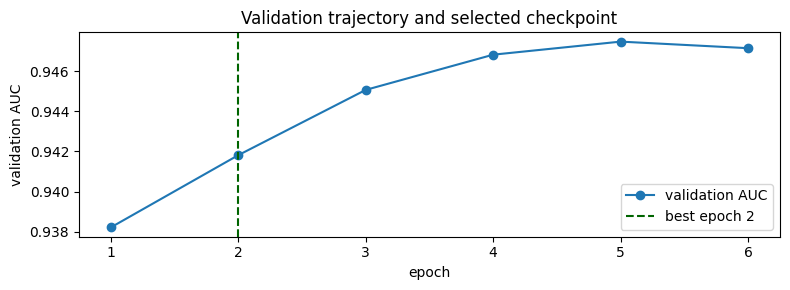

Restored epoch 2: validation nll=0.292896


,epoch,train_loss,train_nll,train_kl_scaled,selection_floor,train_selection_rate,train_denominator_mean,train_denominator_min,stopword_delta,boilerplate_delta,...,val_denominator_min,val_acc,val_f1,val_auc,val_brier,val_nll,val_ece,checkpoint_metric,checkpoint_value,is_best_checkpoint
0,1,0.528171,0.502381,0.108208,0.002087,0.009183,0.301074,0.137963,0.009191,0.009175,...,0.025241,0.844333,0.794545,0.938210,0.106060,0.328503,0.070264,nll,0.328503,True
1,2,0.465209,0.417520,0.107622,0.001696,0.010673,0.350124,0.142287,0.010151,0.012612,...,0.058010,0.870667,0.806965,0.941813,0.092817,0.292896,0.016015,nll,0.292896,True
2,3,0.468906,0.400137,0.106884,0.002361,0.001425,0.046655,0.020255,0.001415,0.001406,...,0.005687,0.860667,0.810517,0.945068,0.096798,0.303713,0.054838,nll,0.303713,False
3,4,0.481436,0.391984,0.106037,0.002422,0.000790,0.025787,0.006905,0.000711,0.000633,...,0.003467,0.844000,0.800851,0.946825,0.107712,0.334711,0.103687,nll,0.334711,False
4,5,0.492034,0.382235,0.105155,0.002429,0.000719,0.023651,0.003976,0.000519,0.000633,...,0.002165,0.864333,0.819191,0.947476,0.099215,0.310388,0.066805,nll,0.310388,False
5,6,0.487331,0.378266,0.104302,0.002423,0.000785,0.025763,0.003607,0.000550,0.000601,...,0.003300,0.852667,0.807323,0.947148,0.104714,0.330780,0.084749,nll,0.330780,False


In [17]:
# ================================================================
# 14. Train with validation-only checkpointing
# ================================================================

# Build the position-aware, selected-token-normalized BAMIC model.
model = BayesianAMICWD(
    embedding_matrix=embedding_matrix,
    hidden_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    prior_sigma_b=1.0,
    prior_sigma_beta=1.0,
    init_rho=-5.0,
    dropout=0.10,
    freeze_embeddings=FREEZE_EMBEDDINGS,
    selection_activation='sigmoid',
    max_len=MAX_LEN,
    use_positional_encoding=USE_POSITIONAL_ENCODING,
    aggregation_mode=AGGREGATION_MODE,
    aggregation_eps=AGGREGATION_EPS,
).to(DEVICE)

print('Trainable parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
n_train = len(train_ds)
history = []

# Test data are deliberately absent from this loop.
best_value = np.inf if CHECKPOINT_MODE == 'min' else -np.inf
best_epoch = None
epochs_without_improvement = 0
stopped_early = False


def validation_improved(current, best):
    """Apply the configured direction and minimum meaningful change."""
    if CHECKPOINT_MODE == 'min':
        return current < (best - CHECKPOINT_MIN_DELTA)
    return current > (best + CHECKPOINT_MIN_DELTA)


for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []
    component_sums = {}

    for batch in train_loader:
        optimizer.zero_grad(set_to_none=True)
        loss, logs = compute_loss(model, batch, epoch, n_train, train_mc_samples=TRAIN_MC_SAMPLES)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        train_losses.append(float(loss.detach().cpu()))
        for key, value in logs.items():
            component_sums[key] = component_sums.get(key, 0.0) + value

    n_batches = max(1, len(train_loader))
    component_means = {key: value / n_batches for key, value in component_sums.items()}

    # Clean checkpoint signal: posterior-mean parameters, dropout off, validation only.
    valid_point = deterministic_predict_loader(model, valid_loader)
    valid_metrics = binary_metrics_from_probs(valid_point['probs'], valid_point['labels'])
    valid_ece = expected_calibration_error(valid_point['probs'], valid_point['labels'])
    checkpoint_value = float(valid_metrics[CHECKPOINT_METRIC])
    improved = validation_improved(checkpoint_value, best_value)

    if improved:
        best_value = checkpoint_value
        best_epoch = epoch
        epochs_without_improvement = 0
        # Saving optimizer state makes it possible to resume this exact best epoch.
        torch.save({
            'epoch': epoch,
            'checkpoint_metric': CHECKPOINT_METRIC,
            'checkpoint_mode': CHECKPOINT_MODE,
            'checkpoint_value': checkpoint_value,
            'validation_metrics': valid_metrics,
            'validation_ece': valid_ece,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'experiment_name': EXPERIMENT_NAME,
        }, BEST_CHECKPOINT_PATH)
    else:
        epochs_without_improvement += 1

    history.append({
        'epoch': epoch,
        'train_loss': float(np.mean(train_losses)),
        'train_nll': component_means.get('nll', np.nan),
        'train_kl_scaled': component_means.get('kl_scaled', np.nan),
        'selection_floor': component_means.get('selection_floor', np.nan),
        'train_selection_rate': component_means.get('selection_rate', np.nan),
        'train_denominator_mean': component_means.get('aggregation_denominator_mean', np.nan),
        'train_denominator_min': component_means.get('aggregation_denominator_min', np.nan),
        'stopword_delta': component_means.get('stopword_delta', np.nan),
        'boilerplate_delta': component_means.get('boilerplate_delta', np.nan),
        'content_delta': component_means.get('content_delta', np.nan),
        'val_selected_mass': valid_point['selected_mass_mean'],
        'val_selection_rate': valid_point['selection_rate_mean'],
        'val_denominator_mean': valid_point['aggregation_denominator_mean'],
        'val_denominator_min': valid_point['aggregation_denominator_min'],
        'val_acc': valid_metrics['acc'],
        'val_f1': valid_metrics['f1'],
        'val_auc': valid_metrics['auc'],
        'val_brier': valid_metrics['brier'],
        'val_nll': valid_metrics['nll'],
        'val_ece': valid_ece,
        'checkpoint_metric': CHECKPOINT_METRIC,
        'checkpoint_value': checkpoint_value,
        'is_best_checkpoint': improved,
    })

    # Persist progress every epoch so a Colab disconnect does not erase history.
    pd.DataFrame(history).to_csv(OUTPUT_DIR / 'history.csv', index=False)

    print(
        f"Epoch {epoch:02d} | loss={np.mean(train_losses):.4f} | "
        f"val_acc={valid_metrics['acc']:.4f} | val_auc={valid_metrics['auc']:.4f} | "
        f"val_nll={valid_metrics['nll']:.4f} | val_select_rate={valid_point['selection_rate_mean']:.4f} | "
        f"{CHECKPOINT_METRIC}={checkpoint_value:.4f} | "
        f"{'SAVED BEST' if improved else f'no improvement ({epochs_without_improvement})'}"
    )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        stopped_early = True
        print(f'Early stopping: validation {CHECKPOINT_METRIC} did not improve for '
              f'{EARLY_STOPPING_PATIENCE} epochs.')
        break

history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / 'history.csv', index=False)

plt.figure(figsize=(8, 3))
plt.plot(history_df['epoch'], history_df['val_auc'], marker='o', label='validation AUC')
if best_epoch is not None:
    plt.axvline(best_epoch, color='darkgreen', linestyle='--', label=f'best epoch {best_epoch}')
plt.xlabel('epoch')
plt.ylabel('validation AUC')
plt.title('Validation trajectory and selected checkpoint')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'val_auc_curve.png', dpi=150)
plt.show()

if not BEST_CHECKPOINT_PATH.exists():
    raise RuntimeError('No validation checkpoint was saved; inspect validation metrics above.')

# Restore the best validation checkpoint BEFORE final train/valid/test evaluation.
try:
    best_checkpoint = torch.load(BEST_CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
except TypeError:  # Compatibility with older PyTorch releases.
    best_checkpoint = torch.load(BEST_CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(best_checkpoint['model_state_dict'])
best_epoch = int(best_checkpoint['epoch'])
best_value = float(best_checkpoint['checkpoint_value'])
print(f'Restored epoch {best_epoch}: validation {CHECKPOINT_METRIC}={best_value:.6f}')

checkpoint_summary = pd.DataFrame([{
    'best_epoch': best_epoch,
    'checkpoint_metric': CHECKPOINT_METRIC,
    'checkpoint_mode': CHECKPOINT_MODE,
    'best_validation_value': best_value,
    'epochs_completed': int(history_df['epoch'].max()),
    'stopped_early': stopped_early,
    'validation_only_selection': True,
    'test_used_for_selection': False,
}])
checkpoint_summary.to_csv(OUTPUT_DIR / 'checkpoint_summary.csv', index=False)

history_df

## Step 6 — Open the holdout only after restoring the validation winner

The test CSV has not been read, summarized, tokenized, or placed in a loader
before this point. This cell constructs the holdout objects once; the following
cell performs the final Monte Carlo evaluation.

In [18]:
# ================================================================
# 15a. Load and prepare the untouched test split after restoration
# ================================================================

test_path = DATA_DIR / 'wine_test.csv'
if not test_path.exists():
    raise FileNotFoundError(
        f'Missing {test_path}. Run 00_prepare_wine_data.ipynb first.'
    )

test_df = pd.read_csv(test_path)
test_df['text'] = test_df['text'].astype(str)
x_test, len_test, y_test = encode_dataframe(test_df)
sw_test, bp_test = build_penalty_masks(test_df, x_test)
test_ds = AMICTextDataset(x_test, y_test, len_test, sw_test, bp_test)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

print('test:', test_df.shape, '| positive rate:', round(test_df['y'].mean(), 4))
print('test batches:', len(test_loader))
print('The restored checkpoint will now be evaluated once on this holdout.')

test: (10000, 3) | positive rate: 0.342
test batches: 79
The restored checkpoint will now be evaluated once on this holdout.


In [19]:
# ================================================================
# 15b. Final evaluation of the restored best-validation checkpoint
# ================================================================

# Use more Monte Carlo samples for the final, reported summaries.
FINAL_MC_SAMPLES = 100

# The model was restored at the end of Step 14. Only now do we evaluate test.
# Use the non-shuffled train loader so saved rows retain train_df order.
train_uncertainty, _ = posterior_predict_loader(model, train_eval_loader, n_samples=FINAL_MC_SAMPLES)
valid_uncertainty, _ = posterior_predict_loader(model, valid_loader, n_samples=FINAL_MC_SAMPLES)
test_uncertainty, _ = posterior_predict_loader(model, test_loader, n_samples=FINAL_MC_SAMPLES)

# Pull the arrays used by the shared metric/saving code.
train_probs = train_uncertainty['p_mean'].to_numpy()
valid_probs = valid_uncertainty['p_mean'].to_numpy()
test_probs = test_uncertainty['p_mean'].to_numpy()
y_train_true = train_uncertainty['y_true'].to_numpy()
y_valid_true = valid_uncertainty['y_true'].to_numpy()
y_test_true = test_uncertainty['y_true'].to_numpy()

# Save the full per-document uncertainty tables for later analysis.
train_uncertainty.to_csv(OUTPUT_DIR / 'train_document_uncertainty.csv', index=False)
valid_uncertainty.to_csv(OUTPUT_DIR / 'valid_document_uncertainty.csv', index=False)
test_uncertainty.to_csv(OUTPUT_DIR / 'test_document_uncertainty.csv', index=False)

# Save one compact denominator/selection summary per split.
denominator_rows = []
for split_name, table in [('train', train_uncertainty),
                          ('valid', valid_uncertainty),
                          ('test', test_uncertainty)]:
    denominator_rows.append({
        'split': split_name,
        'selected_mass_mean': table['selected_mass_mean'].mean(),
        'selection_rate_mean': table['selection_rate_mean'].mean(),
        'selection_rate_min': table['selection_rate_mean'].min(),
        'aggregation_denominator_mean': table['aggregation_denominator_mean'].mean(),
        'aggregation_denominator_min': table['aggregation_denominator_mean'].min(),
        'fraction_selection_rate_below_floor': (
            table['selection_rate_mean'] < MIN_SELECTION_RATE
        ).mean(),
    })
selection_denominator_diagnostics = pd.DataFrame(denominator_rows)
selection_denominator_diagnostics.to_csv(
    OUTPUT_DIR / 'selection_denominator_diagnostics.csv', index=False
)
display(selection_denominator_diagnostics)

test_uncertainty.head()

,split,selected_mass_mean,selection_rate_mean,selection_rate_min,aggregation_denominator_mean,aggregation_denominator_min,fraction_selection_rate_below_floor
0,train,0.179175,0.005480,0.004761,0.179176,0.043777,1.0
1,valid,0.179325,0.005479,0.004822,0.179326,0.057976,1.0
2,test,0.178746,0.005475,0.004766,0.178747,0.049591,1.0


,y_true,p_mean,ci95_lo,ci95_hi,ci_width,var,entropy,bald,prob1,selected_mass_mean,selection_rate_mean,aggregation_denominator_mean,label_by_mean
0,0,0.251609,0.210802,0.298703,0.087902,0.000556,0.564096,0.001477,0.0,0.163977,0.005124,0.163978,0
1,1,0.653995,0.595215,0.705604,0.110390,0.000854,0.644938,0.001888,1.0,0.210180,0.005389,0.210181,1
2,1,0.971182,0.965248,0.977577,0.012329,0.000013,0.130608,0.000223,1.0,0.251199,0.005345,0.251200,1
3,1,0.964800,0.956397,0.972409,0.016012,0.000019,0.152376,0.000285,1.0,0.199837,0.005551,0.199838,1
4,0,0.817427,0.781898,0.851693,0.069795,0.000338,0.475273,0.001129,1.0,0.222485,0.005174,0.222486,1


In [20]:
# ================================================================
# 16. Validation-tuned decision thresholds
# ================================================================

# The default 0.5 threshold is not always optimal for accuracy or F1.
# Following the protocol from the wine Word2Vec analysis, we choose the threshold on
# the VALIDATION split and then apply that frozen choice to the TEST split.
# AUC is unaffected by this (it is threshold-free by construction).

# Candidate thresholds from 0.05 to 0.95 in small steps.
thresholds = np.arange(0.05, 0.951, 0.005)

# Evaluate validation accuracy and F1 at every candidate threshold.
valid_accs, valid_f1s = [], []
for t in thresholds:
    pred = (valid_probs >= t).astype(int)
    valid_accs.append((pred == y_valid_true).mean())
    valid_f1s.append(f1_score(y_valid_true, pred, zero_division=0))

# Pick the thresholds that maximize validation accuracy and validation F1.
best_acc_threshold = float(thresholds[int(np.argmax(valid_accs))])
best_f1_threshold = float(thresholds[int(np.argmax(valid_f1s))])
print('Best validation-accuracy threshold:', round(best_acc_threshold, 3))
print('Best validation-F1 threshold      :', round(best_f1_threshold, 3))


def test_metrics_at(threshold):
    """Compute test accuracy and F1 at a given decision threshold."""
    pred = (test_probs >= threshold).astype(int)
    return {'threshold': round(float(threshold), 3),
            'test_acc': (pred == y_test_true).mean(),
            'test_f1': f1_score(y_test_true, pred, zero_division=0)}


# Report test performance at the default and both tuned thresholds.
threshold_rows = [
    {'rule': 'default 0.5', **test_metrics_at(0.5)},
    {'rule': 'tuned by valid acc', **test_metrics_at(best_acc_threshold)},
    {'rule': 'tuned by valid F1', **test_metrics_at(best_f1_threshold)},
]
threshold_df = pd.DataFrame(threshold_rows)

# Save the threshold analysis next to the other outputs.
threshold_df.to_csv(OUTPUT_DIR / 'threshold_tuning.csv', index=False)

# Display the comparison.
threshold_df

Best validation-accuracy threshold: 0.515
Best validation-F1 threshold      : 0.445


,rule,threshold,test_acc,test_f1
0,default 0.5,0.500,0.8704,0.807772
1,tuned by valid acc,0.515,0.8707,0.806871
2,tuned by valid F1,0.445,0.8725,0.816044


In [21]:
# ================================================================
# 16. Is the uncertainty informative? Wrong vs. correct predictions
# ================================================================

# Mark which test predictions are wrong at the posterior-mean threshold of 0.5.
wrong = (test_uncertainty['label_by_mean'] != test_uncertainty['y_true'])

# Compare mean entropy and credible-interval width between wrong and correct predictions.
summary = pd.DataFrame({
    'wrong_mean': test_uncertainty.loc[wrong, ['entropy', 'ci_width', 'var', 'bald']].mean(),
    'correct_mean': test_uncertainty.loc[~wrong, ['entropy', 'ci_width', 'var', 'bald']].mean(),
})

# Add the wrong-to-correct ratio; values well above 1 mean uncertainty is informative.
summary['ratio_wrong_over_correct'] = summary['wrong_mean'] / summary['correct_mean']

# Save the diagnostic table.
summary.to_csv(OUTPUT_DIR / 'uncertainty_wrong_vs_correct.csv')

# Display it in the notebook.
summary

,wrong_mean,correct_mean,ratio_wrong_over_correct
entropy,0.539812,0.237022,2.277479
ci_width,0.079525,0.030739,2.587088
var,0.000501,0.000146,3.439346
bald,0.001217,0.000473,2.571280


In [22]:
# ================================================================
# 17. Word-level posterior uncertainty for one test sentence
# ================================================================

# Number of posterior samples for the word-level analysis.
WORD_MC_SAMPLES = 100

# Pick one test sentence to explain (change this index to explore other examples).
EXAMPLE_INDEX = 0

# Get the encoded ids of the chosen sentence as a batch of size 1.
example_ids = torch.tensor(x_test[EXAMPLE_INDEX:EXAMPLE_INDEX + 1], dtype=torch.long).to(DEVICE)

# Print the raw sentence and its true label.
print('Sentence:', test_df['text'].iloc[EXAMPLE_INDEX])
print('True label:', int(test_df['y'].iloc[EXAMPLE_INDEX]), '(1 = positive)')

# Collect per-sample word-level quantities without gradients.
delta_samples, z_samples, gated_samples, raw_samples = [], [], [], []
with torch.no_grad():
    # Eval mode turns dropout off so only (b, beta) sampling drives the variation.
    model.eval()
    for _ in range(WORD_MC_SAMPLES):
        # One forward pass = one posterior sample.
        out = model(example_ids, sample=True)
        # All four arrays must receive every posterior draw.
        delta_samples.append(out['delta'][0].cpu().numpy())
        # word_logit is the normalized additive contribution in this variant.
        z_samples.append(out['word_logit'][0].cpu().numpy())
        # gated_word_score is the legacy numerator delta * raw sentiment.
        gated_samples.append(out['gated_word_score'][0].cpu().numpy())
        raw_samples.append(out['raw_word_sentiment'][0].cpu().numpy())

# Stack to arrays of shape [S, MAX_LEN].
delta_samples = np.stack(delta_samples)
z_samples = np.stack(z_samples)
gated_samples = np.stack(gated_samples)
raw_samples = np.stack(raw_samples)

# The real (unpadded) length of this sentence.
real_len = int(len_test[EXAMPLE_INDEX])

# Build one row per real token with posterior summaries.
rows = []
for j in range(real_len):
    rows.append({
        'position': j,
        'word': id_to_word.get(int(x_test[EXAMPLE_INDEX, j]), '<UNK>'),
        'delta_mean': delta_samples[:, j].mean(),
        'delta_sd': delta_samples[:, j].std(),
        'z_mean': z_samples[:, j].mean(),
        'gated_score_mean': gated_samples[:, j].mean(),
        'z_sd': z_samples[:, j].std(),
        'z_ci95_lo': np.quantile(z_samples[:, j], 0.025),
        'z_ci95_hi': np.quantile(z_samples[:, j], 0.975),
        'p_z_positive': (z_samples[:, j] > 0).mean(),
    })

# Sort tokens by absolute mean contribution so the strongest words appear first.
word_table = pd.DataFrame(rows).sort_values('z_mean', key=np.abs, ascending=False)

# Save the word-level table for the paper.
word_table.to_csv(OUTPUT_DIR / 'example_word_uncertainty.csv', index=False)

# Display the top rows.
word_table.head(15)

Sentence: A rich version, displaying cherry, plum and floral notes married to a vibrant profile. Though firm, this stays balanced and long on the finish. Drink now through 2020. 2,000 cases made.
True label: 0 (1 = positive)


,position,word,delta_mean,delta_sd,z_mean,gated_score_mean,z_sd,z_ci95_lo,z_ci95_hi,p_z_positive
29,29,000,0.005153,0.000659,-0.068354,-0.011758,0.003044,-0.074648,-0.062546,0.0
30,30,cases,0.005263,0.000672,-0.065368,-0.011247,0.003117,-0.071507,-0.059203,0.0
13,13,profile,0.005213,0.000666,-0.064876,-0.011161,0.003072,-0.071240,-0.058842,0.0
9,9,married,0.005364,0.000685,-0.063589,-0.010941,0.003173,-0.070253,-0.057191,0.0
14,14,though,0.005368,0.000685,-0.058240,-0.010022,0.003171,-0.064768,-0.051825,0.0
17,17,stays,0.005282,0.000675,-0.056429,-0.009710,0.003110,-0.062912,-0.050127,0.0
15,15,firm,0.005205,0.000665,-0.055678,-0.009581,0.003066,-0.062052,-0.049592,0.0
8,8,notes,0.005168,0.000661,-0.053890,-0.009274,0.003046,-0.060192,-0.047886,0.0
3,3,displaying,0.005199,0.000664,-0.052906,-0.009105,0.003064,-0.059213,-0.046769,0.0
25,25,now,0.005340,0.000682,-0.047930,-0.008251,0.003155,-0.054380,-0.041501,0.0


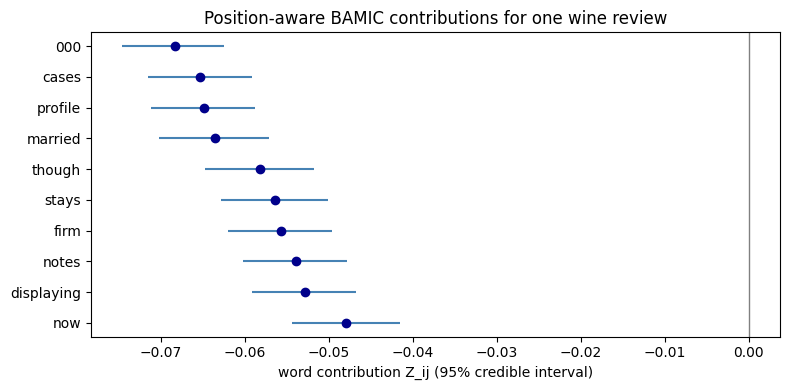

In [23]:
# ================================================================
# 18. Plot posterior intervals for the word contributions
# ================================================================

# Take the ten words with the largest absolute mean contribution.
top = word_table.head(10).iloc[::-1]

# Draw a horizontal interval plot: one line per word.
plt.figure(figsize=(8, 4))
# The horizontal line spans the 95% credible interval of each word's contribution.
plt.hlines(y=range(len(top)), xmin=top['z_ci95_lo'], xmax=top['z_ci95_hi'], color='steelblue')
# The dot marks the posterior mean contribution.
plt.plot(top['z_mean'], range(len(top)), 'o', color='darkblue')
# A vertical line at zero separates negative from positive contributions.
plt.axvline(0.0, color='gray', linewidth=1)
# Label each row with its word.
plt.yticks(range(len(top)), top['word'])
plt.xlabel('word contribution Z_ij (95% credible interval)')
plt.title('Position-aware BAMIC contributions for one wine review')
plt.tight_layout()
# Save the figure into the output folder for the paper.
plt.savefig(OUTPUT_DIR / 'example_word_contribution_intervals.png', dpi=150)
plt.show()

In [24]:
# ================================================================
# 19. Corpus-level word sentiment table (validation split)
# ================================================================

# Number of posterior samples per batch for the corpus scan.
CORPUS_MC_SAMPLES = 20

# Accumulate per-word statistics across the validation split.
word_stats = {}

with torch.no_grad():
    # Eval mode keeps dropout off.
    model.eval()
    # Walk over validation batches.
    for batch in valid_loader:
        # Move ids to the GPU.
        input_ids = batch['input_ids'].to(DEVICE)
        # Average delta and Z over posterior samples for this batch.
        delta_sum = torch.zeros(input_ids.shape, dtype=torch.float32)
        z_sum = torch.zeros(input_ids.shape, dtype=torch.float32)
        for _ in range(CORPUS_MC_SAMPLES):
            out = model(input_ids, sample=True)
            delta_sum += out['delta'].cpu()
            z_sum += out['word_logit'].cpu()
        delta_mean = (delta_sum / CORPUS_MC_SAMPLES).numpy()
        z_mean = (z_sum / CORPUS_MC_SAMPLES).numpy()
        # Accumulate statistics per vocabulary word.
        ids = input_ids.cpu().numpy()
        for i in range(ids.shape[0]):
            for j in range(ids.shape[1]):
                # Skip padding.
                if ids[i, j] == 0:
                    break
                word = id_to_word.get(int(ids[i, j]), '<UNK>')
                stats = word_stats.setdefault(word, {'count': 0, 'delta_sum': 0.0, 'z_sum': 0.0})
                stats['count'] += 1
                stats['delta_sum'] += float(delta_mean[i, j])
                stats['z_sum'] += float(z_mean[i, j])

# Convert the accumulated statistics into a table (words seen at least 5 times).
corpus_rows = []
for word, stats in word_stats.items():
    if stats['count'] >= 5:
        corpus_rows.append({
            'word': word,
            'count': stats['count'],
            'delta_mean': stats['delta_sum'] / stats['count'],
            'z_mean': stats['z_sum'] / stats['count'],
        })

# Sort by absolute average contribution so the strongest sentiment words appear first.
corpus_table = pd.DataFrame(corpus_rows).sort_values('z_mean', key=np.abs, ascending=False)

# Count how many of the top-100 words are penalized stopwords (contamination check).
top100 = corpus_table.head(100)
stopword_contamination = int(top100['word'].isin(STOPWORD_PENALTY_WORDS).sum())
print('Stopword contamination in top-100 corpus words:', stopword_contamination)

# Save the corpus-level table for the paper.
corpus_table.to_csv(OUTPUT_DIR / 'corpus_word_sentiment.csv', index=False)

# Display the strongest 20 words.
corpus_table.head(20)

Stopword contamination in top-100 corpus words: 1


,word,count,delta_mean,z_mean
1254,quick,5,0.005345,-0.309777
207,simple,21,0.005431,-0.258699
306,straightforward,29,0.005302,-0.247062
389,easygoing,18,0.005486,-0.209033
356,modest,135,0.005267,-0.204501
213,scale,6,0.005373,-0.203110
450,easy,28,0.005373,-0.196981
1143,shadings,5,0.005300,-0.196455
1140,hay,6,0.005161,-0.194206
882,herbaceous,5,0.005566,-0.193041


## Step 7 — Save the same artifact family plus checkpoint provenance

Existing downstream comparison code can still read `final_metrics.csv`,
`history.csv`, uncertainty CSVs, figures, and the state dict. The new
`checkpoint_summary.csv` and `best_validation_checkpoint.pt` record why the
final weights were chosen.

In [25]:
# ================================================================
# 22. Save final metrics and the run configuration
# ================================================================

# Collect one metrics row per split so the comparison table can read them later.
final_metric_rows = []

# Loop over the three splits with their posterior-mean probabilities and true labels.
for split_name, probs, labels in [('train', train_probs, y_train_true),
                                  ('valid', valid_probs, y_valid_true),
                                  ('test', test_probs, y_test_true)]:
    # Compute accuracy, F1, AUC, Brier, and NLL for this split.
    metrics = binary_metrics_from_probs(probs, labels)
    # Compute the calibration error for this split.
    ece = expected_calibration_error(probs, labels)
    # Store everything in one row.
    final_metric_rows.append({'split': split_name, **metrics, 'ece': ece})
    # Print the row so we can see the result immediately.
    print(split_name, {k: round(v, 4) for k, v in metrics.items()}, 'ece=', round(ece, 4))

# Convert the rows into a small dataframe and save it.
pd.DataFrame(final_metric_rows).to_csv(OUTPUT_DIR / 'final_metrics.csv', index=False)

# Also record the exact run configuration for reproducibility.
pd.DataFrame([{
    'freeze_embeddings': FREEZE_EMBEDDINGS,
    'epochs': ABLATION_EPOCHS,
    'num_heads': NUM_HEADS,
    'lambda_boilerplate': LAMBDA_BOILERPLATE,
    'lambda_stopword': LAMBDA_STOPWORD,
    'stopword_warmup_epochs': STOPWORD_WARMUP_EPOCHS,
    'learning_rate': BAMIC_LEARNING_RATE,
    'max_len': MAX_LEN,
    'batch_size': BATCH_SIZE,
    'use_positional_encoding': USE_POSITIONAL_ENCODING,
    'position_encoding_type': POSITION_ENCODING_TYPE,
    'aggregation_mode': AGGREGATION_MODE,
    'aggregation_eps': AGGREGATION_EPS,
    'use_selection_floor_guard': USE_SELECTION_FLOOR_GUARD,
    'min_selection_rate': MIN_SELECTION_RATE,
    'lambda_selection_floor': LAMBDA_SELECTION_FLOOR,
    'checkpoint_metric': CHECKPOINT_METRIC,
    'checkpoint_mode': CHECKPOINT_MODE,
    'checkpoint_min_delta': CHECKPOINT_MIN_DELTA,
    'early_stopping_patience': EARLY_STOPPING_PATIENCE,
    'best_epoch': best_epoch,
    'best_validation_value': best_value,
    'best_acc_threshold': best_acc_threshold,
    'best_f1_threshold': best_f1_threshold,
}]).to_csv(OUTPUT_DIR / 'run_config.csv', index=False)

# Save the RESTORED BEST-validation weights using the legacy artifact name.
# `best_validation_checkpoint.pt` additionally contains optimizer/checkpoint metadata.
torch.save(model.state_dict(), OUTPUT_DIR / 'bamic_wine_state_dict.pt')

# Confirm where everything was written.
print('Saved final metrics, thresholds, run config, checkpoint/denominator metadata, and best weights to:')
print(OUTPUT_DIR)

train {'acc': 0.872, 'f1': 0.81, 'auc': np.float64(0.9455), 'brier': np.float64(0.0895), 'nll': 0.2825} ece= 0.0137
valid {'acc': 0.872, 'f1': 0.809, 'auc': np.float64(0.9419), 'brier': np.float64(0.0928), 'nll': 0.2928} ece= 0.0166
test {'acc': 0.8704, 'f1': 0.8078, 'auc': np.float64(0.9445), 'brier': np.float64(0.0904), 'nll': 0.2854} ece= 0.0147
Saved final metrics, thresholds, run config, checkpoint/denominator metadata, and best weights to:
/content/drive/MyDrive/AMIC project/wine_benchmark/outputs/wine_bamic_posenc_selnorm_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100
